# Card Fraud Detection using Logistic Regression and MLP with Mini-batch Gradient Descent

I have prepared two models for a binary classification problem to detect fraudulent transactions.

- **Baseline model:** Logistic Regression implemented from scratch
- **Neural network model:** Multi-Layer Perceptron (MLP) implemented from scratch

Both models are trained with **mini-batch gradient descent**. The goal is to compare their performance on an real-world dataset collected from the kaggle and see which one gives a better balance between detecting fraud and avoiding too many false alarms.

In [1]:
import os
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)

## Dataset selection

I chose this dataset because it represents a binary classification problem with a large number of transactions and around 30 features. It reflects a real-world scenario where class imbalance is important, making it useful for comparing models like Logistic Regression and an MLP. Since I work in the banking domain, this problem also aligns well with my current role and helps me relate the concepts to practical use cases.

Please note that the dataset was taken from Kaggle and loaded locally as creditcard.csv.

The target variable is Class, where 0 represents a normal transaction and 1 represents a fraudulent transaction. All the predictor variables are numeric, so after applying feature scaling, the dataset can be used directly for model training.

In [2]:
dataset_name = "creditcard.csv"

try:
    df = pd.read_csv(dataset_name)
except Exception as e:
    print(f"Could not load from directory: {e}")

print("Shape of dataset:", df.shape)
print("Columns:")
print(df.columns.tolist())
df.head()

Shape of dataset: (284807, 31)
Columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
n_samples, n_total_columns = df.shape
target_column = "Class"
feature_columns = [col for col in df.columns if col != target_column]
n_features = len(feature_columns)
problem_type = "Binary Classification"
primary_metric = "F1-score"

print(f"Dataset name      : {dataset_name}")
print(f"Number of samples : {n_samples}")
print(f"Number of features: {n_features}")
print(f"Problem type      : {problem_type}")
print(f"Primary metric    : {primary_metric}")
print()
print("Data types:")
print(df.dtypes)

Dataset name      : creditcard.csv
Number of samples : 284807
Number of features: 30
Problem type      : Binary Classification
Primary metric    : F1-score

Data types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


### F1-score as the primary metric

The chosen dataset is highly imbalanced because fraud cases are much fewer than normal transactions.  
Because of that, accuracy alone can be misleading. A model can get very high accuracy just by predicting most cases as non-fraud.

For this reason, I use **F1-score** as the primary metric. It combines **precision** and **recall**, so it is better for judging how well the model identifies fraud cases while also controlling false alarms.

## Exploratory Data Analysis (EDA)

In [4]:
print("Basic summary statistics:")
display(df.describe().T)

print("\nMissing values per column:")
display(df.isnull().sum().to_frame("missing_count").T)

class_counts = df["Class"].value_counts().sort_index()
class_percentages = (df["Class"].value_counts(normalize=True).sort_index() * 100).round(4)

eda_summary = pd.DataFrame({
    "class": class_counts.index,
    "count": class_counts.values,
    "percentage": class_percentages.values
})

display(eda_summary)

Basic summary statistics:


,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995



Missing values per column:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
missing_count,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


,class,count,percentage
0,0,284315,99.8273
1,1,492,0.1727


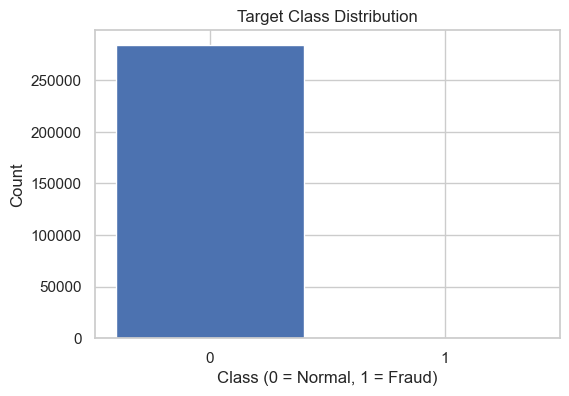

Fraud ratio in the dataset: 0.001727 (0.1727%)


In [5]:
class_counts_plot = df["Class"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(class_counts_plot.index.astype(str), class_counts_plot.values)
plt.title("Target Class Distribution")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

fraud_ratio = df["Class"].mean()
print(f"Fraud ratio in the dataset: {fraud_ratio:.6f} ({fraud_ratio*100:.4f}%)")

### EDA observations

- The dataset is strongly imbalanced, with fraud cases forming only a very small part of the data.
- All predictor columns are numeric, so no categorical encoding is needed.
- Since many features are already transformed, summary statistics are useful mainly for a quick inspection rather than direct business interpretation.

## Plots for input variables

In [6]:
categorical_columns = df[feature_columns].select_dtypes(include=["object", "category"]).columns.tolist()
numeric_columns = df[feature_columns].select_dtypes(include=[np.number]).columns.tolist()

print("Categorical input columns:", categorical_columns)
print("Numeric input columns:", len(numeric_columns))

Categorical input columns: []
Numeric input columns: 30


In [7]:
if len(categorical_columns) == 0:
    print("This dataset has no categorical input columns, so categorical count plots are not applicable.")
else:
    n_cols = 2
    n_rows = math.ceil(len(categorical_columns) / n_cols)
    plt.figure(figsize=(14, 5 * n_rows))
    for i, col in enumerate(categorical_columns, start=1):
        plt.subplot(n_rows, n_cols, i)
        sns.countplot(data=df, x=col, order=df[col].value_counts().index)
        plt.title(f"Count plot of {col}")
        plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

This dataset has no categorical input columns, so categorical count plots are not applicable.


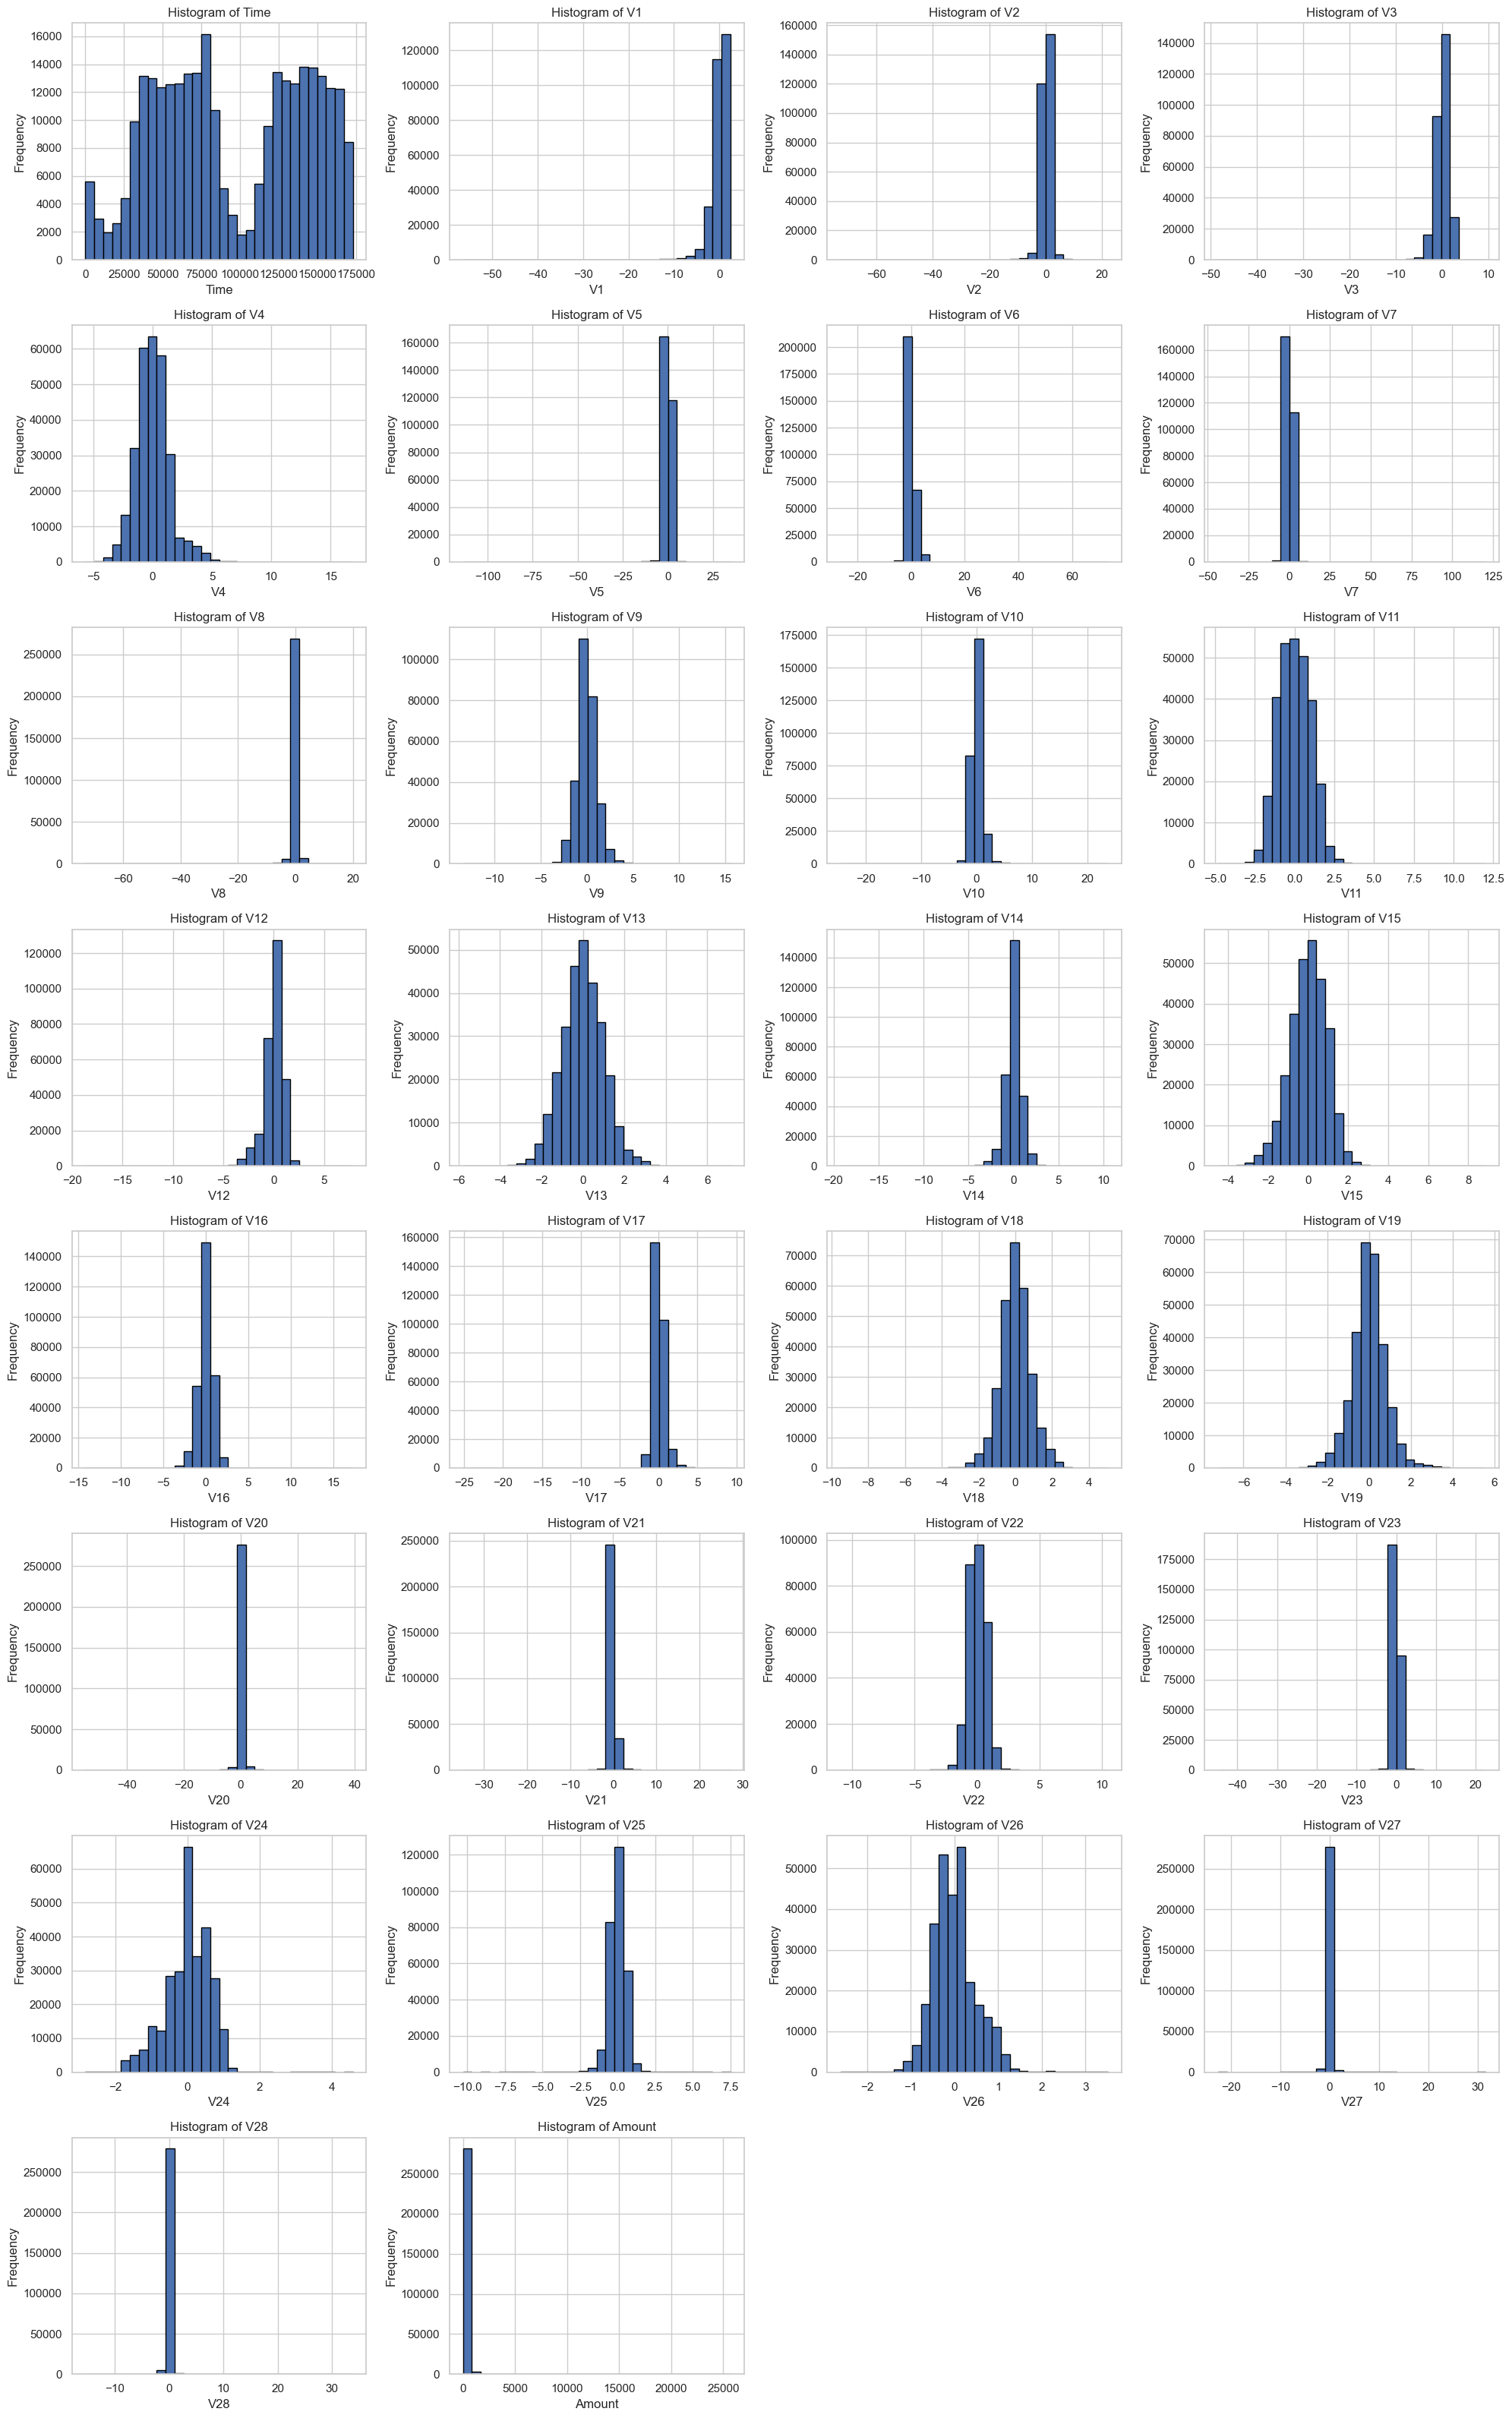

In [8]:
n_cols = 4
n_rows = math.ceil(len(numeric_columns) / n_cols)

plt.figure(figsize=(20, 4 * n_rows))
for i, col in enumerate(numeric_columns, start=1):
    plt.subplot(n_rows, n_cols, i)
    plt.hist(df[col], bins=30, edgecolor="black")
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Plot inference

- This dataset does not have categorical input columns, so count plots for predictors are not needed.
- Most variables are already transformed and centered around small values.
- `Time` and `Amount` have a different scale from the PCA-like features, which is one reason feature scaling is important before training.

## Data preprocessing

I first checked the dataset for missing values before training the models. 
In this dataset, no missing values were found, so no imputation step was needed. Although i've written the generic steps to handle such datasets.

I performed the scaling because gradient descent usually works better when features are on a comparable scale.

In [9]:
df_processed = df.copy()

missing_before = df_processed.isnull().sum().sum()
print("Total missing values before imputation:", missing_before)

# Imputation:
for col in feature_columns:
    if df_processed[col].dtype.kind in "biufc":
        df_processed[col] = df_processed[col].fillna(df_processed[col].median())
    else:
        df_processed[col] = df_processed[col].fillna(df_processed[col].mode()[0])

missing_after = df_processed.isnull().sum().sum()
print("Total missing values after imputation:", missing_after)

Total missing values before imputation: 0
Total missing values after imputation: 0


In [10]:
X = df_processed[feature_columns].copy()
y = df_processed[target_column].copy().values.reshape(-1, 1)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=42, stratify=y_train_full
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Train shape      :", X_train_scaled.shape)
print("Validation shape :", X_val_scaled.shape)
print("Test shape       :", X_test_scaled.shape)

Train shape      : (193668, 30)
Validation shape : (34177, 30)
Test shape       : (56962, 30)


I used an **80-20 split** for train and test data, and then created a **validation split from the training data**.
The validation set is used only for **threshold tuning**. The final comparison between Logistic Regression and MLP is reported on the **test set**.

## Utility functions

In [11]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def binary_cross_entropy(y_true, y_prob, sample_weights=None):
    y_true = np.asarray(y_true).reshape(-1)
    y_prob = np.asarray(y_prob).reshape(-1)
    eps = 1e-12
    y_prob = np.clip(y_prob, eps, 1 - eps)

    if sample_weights is None:
        sample_weights = np.ones_like(y_true, dtype=float)
    else:
        sample_weights = np.asarray(sample_weights).reshape(-1)

    loss = -(sample_weights * y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))
    return float(np.mean(loss))

def custom_confusion_matrix(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1).astype(int)
    y_pred = np.asarray(y_pred).reshape(-1).astype(int)

    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))
    tp = int(np.sum((y_true == 1) & (y_pred == 1)))

    return np.array([[tn, fp], [fn, tp]])

def compute_classification_metrics(y_true, y_pred):
    cm = custom_confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    total = tn + fp + fn + tp
    accuracy = (tp + tn) / total if total else 0.0
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) else 0.0

    return {
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

def evaluate_classification(y_true, y_pred, y_prob=None):
    metrics = compute_classification_metrics(y_true, y_pred)
    return {
        "accuracy": metrics["accuracy"],
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1": metrics["f1"],
    }

def find_best_threshold(y_true, y_prob, metric="f1"):
    thresholds = np.linspace(0.05, 0.95, 19)
    best_threshold = 0.50
    best_score = -1.0

    for threshold in thresholds:
        preds = (np.asarray(y_prob).reshape(-1) >= threshold).astype(int)
        metrics = compute_classification_metrics(y_true, preds)
        score = metrics["f1"] if metric == "f1" else metrics["accuracy"]

        if score > best_score:
            best_score = score
            best_threshold = float(threshold)

    return best_threshold, float(best_score)

## Logistic Regression using Mini-batch Gradient Descent

In [12]:
class LogisticRegressionMiniBatch:
    def __init__(self, learning_rate=0.01, epochs=50, batch_size=2048, pos_weight=1.0, random_state=42):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.pos_weight = pos_weight
        self.random_state = random_state
        self.loss_history = []
        self.epoch_loss_history = []
        self.training_time = None
        self.weights = None
        self.bias = None

    def init(self):
        self.weights = np.zeros((self.n_features_, 1))
        self.bias = 0.0

    def fit(self, X, y):
        start_time = time.time()

        self.n_samples_, self.n_features_ = X.shape
        self.init()
        self.loss_history = []
        self.epoch_loss_history = []

        rng = np.random.default_rng(self.random_state)

        for epoch in range(self.epochs):
            indices = rng.permutation(self.n_samples_)
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            epoch_losses = []

            for start in range(0, self.n_samples_, self.batch_size):
                end = start + self.batch_size
                X_batch = X_shuffled[start:end]
                y_batch = y_shuffled[start:end]

                linear_output = X_batch @ self.weights + self.bias
                y_prob = sigmoid(linear_output)

                sample_weights = np.where(y_batch == 1, self.pos_weight, 1.0)
                error = (y_prob - y_batch) * sample_weights

                dw = (X_batch.T @ error) / len(X_batch)
                db = np.mean(error)

                self.weights -= self.learning_rate * dw
                self.bias -= self.learning_rate * db

                batch_loss = binary_cross_entropy(y_batch, y_prob, sample_weights=sample_weights)
                self.loss_history.append(float(batch_loss))
                epoch_losses.append(float(batch_loss))

            self.epoch_loss_history.append(float(np.mean(epoch_losses)))

        self.training_time = time.time() - start_time
        return self

    def predict_probability(self, X):
        linear_output = X @ self.weights + self.bias
        return sigmoid(linear_output).ravel()

    def predict(self, X, threshold=0.5):
        probabilities = self.predict_probability(X)
        return (probabilities >= threshold).astype(int)

## MLP using Mini-batch Gradient Descent
Architecture: [no_of_features, 16, 8, 1]

- **Hidden layers**: ReLU activation
- **Output layer**: Sigmoid activation for binary classification
- **Loss**: Binary cross-entropy
- **Weight initialisation**: He initialisation
- **Mandatory methods**: `__init__`, `initialize_parameters`, `forward_propagation`, `backward_propagation`, `fit`, `predict`

In [13]:
class MLPMiniBatch:
    def __init__(self, architecture, learning_rate=0.01, epochs=500, batch_size=2048, pos_weight=1.0, random_state=42):
        self.architecture = architecture
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.pos_weight = pos_weight
        self.random_state = random_state
        self.loss_history = []
        self.epoch_loss_history = []
        self.training_time = None
        self.parameters = {}

    def init(self):
        self.initialize_parameters()

    def initialize_parameters(self):
        rng = np.random.default_rng(self.random_state)
        self.parameters = {}

        for layer in range(1, len(self.architecture)):
            n_in = self.architecture[layer - 1]
            n_out = self.architecture[layer]

            if layer < len(self.architecture) - 1:
                scale = np.sqrt(2.0 / n_in)
            else:
                scale = np.sqrt(1.0 / n_in)

            self.parameters[f"W{layer}"] = rng.normal(0, scale, size=(n_in, n_out))
            self.parameters[f"b{layer}"] = np.zeros((1, n_out))

    def forward_propagation(self, X):
        cache = {"A0": X}
        A = X
        L = len(self.architecture) - 1

        for layer in range(1, L):
            Z = A @ self.parameters[f"W{layer}"] + self.parameters[f"b{layer}"]
            A = relu(Z)
            cache[f"Z{layer}"] = Z
            cache[f"A{layer}"] = A

        Z_final = A @ self.parameters[f"W{L}"] + self.parameters[f"b{L}"]
        A_final = sigmoid(Z_final)

        cache[f"Z{L}"] = Z_final
        cache[f"A{L}"] = A_final

        return A_final, cache

    def backward_propagation(self, y, cache):
        grads = {}
        L = len(self.architecture) - 1
        m = len(y)

        A_final = cache[f"A{L}"]
        sample_weights = np.where(y == 1, self.pos_weight, 1.0)

        dZ = (A_final - y) * sample_weights
        grads[f"dW{L}"] = (cache[f"A{L-1}"].T @ dZ) / m
        grads[f"db{L}"] = np.sum(dZ, axis=0, keepdims=True) / m

        dA_prev = dZ @ self.parameters[f"W{L}"].T

        for layer in range(L - 1, 0, -1):
            dZ = dA_prev * relu_derivative(cache[f"Z{layer}"])
            grads[f"dW{layer}"] = (cache[f"A{layer-1}"].T @ dZ) / m
            grads[f"db{layer}"] = np.sum(dZ, axis=0, keepdims=True) / m

            if layer > 1:
                dA_prev = dZ @ self.parameters[f"W{layer}"].T

        return grads

    def fit(self, X, y):
        start_time = time.time()

        self.init()
        self.loss_history = []
        self.epoch_loss_history = []
        n_samples = X.shape[0]
        L = len(self.architecture) - 1
        rng = np.random.default_rng(self.random_state)

        for epoch in range(self.epochs):
            indices = rng.permutation(n_samples)
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            epoch_losses = []

            for start in range(0, n_samples, self.batch_size):
                end = start + self.batch_size
                X_batch = X_shuffled[start:end]
                y_batch = y_shuffled[start:end]

                y_prob, cache = self.forward_propagation(X_batch)
                sample_weights = np.where(y_batch == 1, self.pos_weight, 1.0)
                loss = binary_cross_entropy(y_batch, y_prob, sample_weights=sample_weights)
                grads = self.backward_propagation(y_batch, cache)

                for layer in range(1, L + 1):
                    self.parameters[f"W{layer}"] -= self.learning_rate * grads[f"dW{layer}"]
                    self.parameters[f"b{layer}"] -= self.learning_rate * grads[f"db{layer}"]

                self.loss_history.append(float(loss))
                epoch_losses.append(float(loss))

            self.epoch_loss_history.append(float(np.mean(epoch_losses)))

        self.training_time = time.time() - start_time
        return self

    def predict_probability(self, X):
        probabilities, _ = self.forward_propagation(X)
        return probabilities.ravel()

    def predict(self, X, threshold=0.5):
        probabilities = self.predict_probability(X)
        return (probabilities >= threshold).astype(int)

## Train both models

In [14]:
positive_class_weight = float((len(y_train) - y_train.sum()) / y_train.sum())
print("Positive class weight used in weighted loss:", round(positive_class_weight, 4))

log_model = LogisticRegressionMiniBatch(
    learning_rate=0.01,
    epochs=100,
    batch_size=2048,
    pos_weight=positive_class_weight,
    random_state=42
)

mlp_model = MLPMiniBatch(
    architecture=[X_train_scaled.shape[1], 32, 16, 1],
    learning_rate=0.01,
    epochs=100,
    batch_size=2048,
    pos_weight=positive_class_weight,
    random_state=42
)

log_model.fit(X_train_scaled, y_train)
mlp_model.fit(X_train_scaled, y_train)

print("Logistic Regression training time (seconds):", round(log_model.training_time, 4))
print("MLP training time (seconds):", round(mlp_model.training_time, 4))

Positive class weight used in weighted loss: 577.1134
Logistic Regression training time (seconds): 2.4704
MLP training time (seconds): 7.4078


## Validation-based threshold tuning

In [15]:
log_val_prob = log_model.predict_probability(X_val_scaled)
mlp_val_prob = mlp_model.predict_probability(X_val_scaled)

log_best_threshold, log_best_val_f1 = find_best_threshold(y_val.ravel(), log_val_prob, metric="f1")
mlp_best_threshold, mlp_best_val_f1 = find_best_threshold(y_val.ravel(), mlp_val_prob, metric="f1")

print("Best validation threshold for Logistic Regression:", log_best_threshold)
print("Best validation F1 for Logistic Regression      :", round(log_best_val_f1, 4))
print()
print("Best validation threshold for MLP:", mlp_best_threshold)
print("Best validation F1 for MLP      :", round(mlp_best_val_f1, 4))

Best validation threshold for Logistic Regression: 0.95
Best validation F1 for Logistic Regression      : 0.5

Best validation threshold for MLP: 0.95
Best validation F1 for MLP      : 0.6395


## Evaluation

In [16]:
log_test_prob = log_model.predict_probability(X_test_scaled)
mlp_test_prob = mlp_model.predict_probability(X_test_scaled)

log_test_pred = log_model.predict(X_test_scaled, threshold=log_best_threshold)
mlp_test_pred = mlp_model.predict(X_test_scaled, threshold=mlp_best_threshold)

log_metrics = evaluate_classification(y_test.ravel(), log_test_pred, log_test_prob)
mlp_metrics = evaluate_classification(y_test.ravel(), mlp_test_pred, mlp_test_prob)

results_df = pd.DataFrame([log_metrics, mlp_metrics], index=["Logistic Regression (Mini-batch GD)", "MLP (Mini-batch GD)"])
display(results_df)

,accuracy,precision,recall,f1
Logistic Regression (Mini-batch GD),0.997349,0.383260,0.887755,0.535385
MLP (Mini-batch GD),0.998455,0.532051,0.846939,0.653543


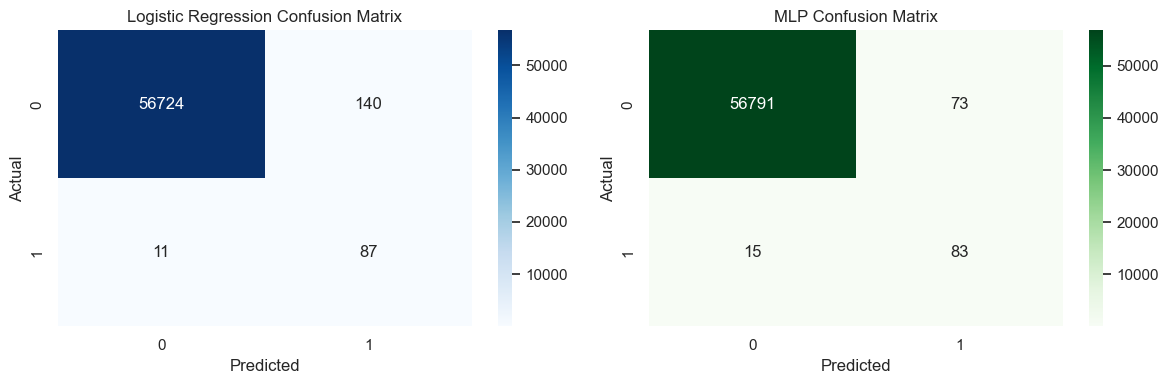

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_log = custom_confusion_matrix(y_test.ravel(), log_test_pred)
cm_mlp = custom_confusion_matrix(y_test.ravel(), mlp_test_pred)

sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Logistic Regression Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_mlp, annot=True, fmt="d", cmap="Greens", ax=axes[1])
axes[1].set_title("MLP Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

### Loss comparison plots

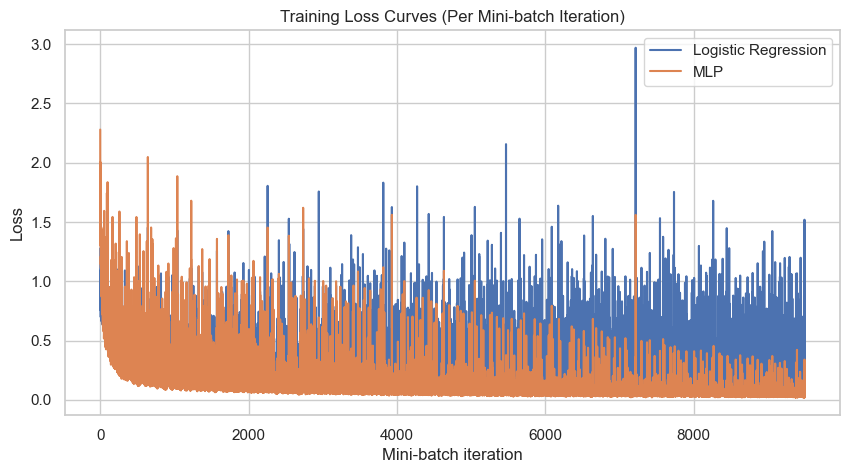

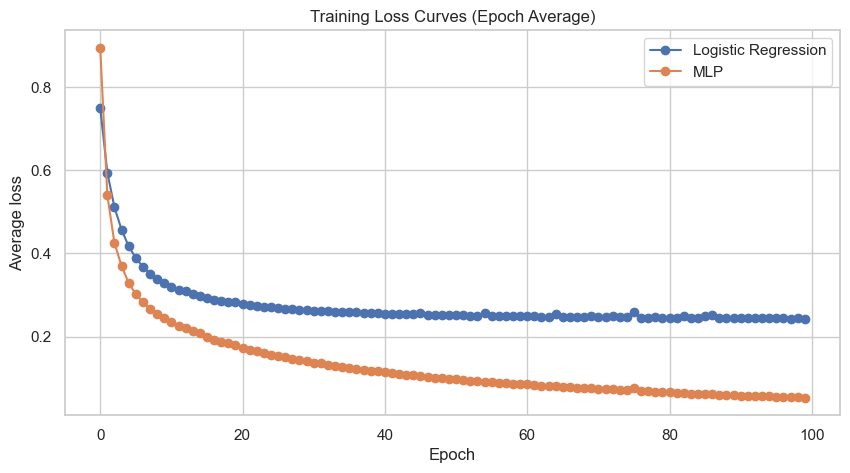

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(log_model.loss_history, label="Logistic Regression")
plt.plot(mlp_model.loss_history, label="MLP")
plt.title("Training Loss Curves (Per Mini-batch Iteration)")
plt.xlabel("Mini-batch iteration")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(log_model.epoch_loss_history, marker="o", label="Logistic Regression")
plt.plot(mlp_model.epoch_loss_history, marker="o", label="MLP")
plt.title("Training Loss Curves (Epoch Average)")
plt.xlabel("Epoch")
plt.ylabel("Average loss")
plt.legend()
plt.show()

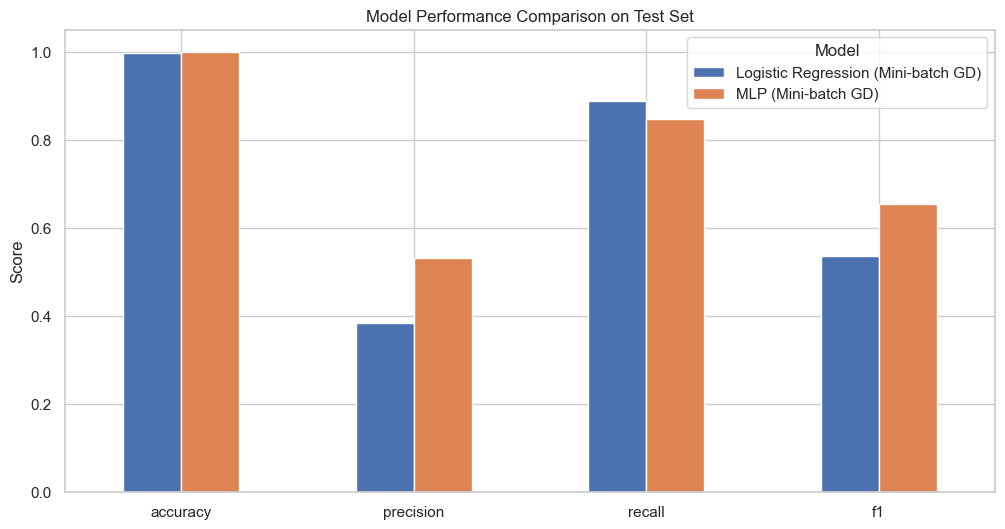

In [19]:
metrics_to_plot = ["accuracy", "precision", "recall", "f1"]
comparison_df = results_df[metrics_to_plot].T

ax = comparison_df.plot(kind="bar", figsize=(12, 6))
plt.title("Model Performance Comparison on Test Set")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.legend(title="Model")
plt.show()

In [20]:
def get_assignment_results():
    baseline_model_results = {
        "model_name": "Logistic Regression (Mini-batch GD)",
        "test_performance": log_metrics,
        "best_threshold": float(log_best_threshold),
        "training_time_seconds": float(log_model.training_time),
        "loss_points_recorded": int(len(log_model.loss_history))
    }

    mlp_model_results = {
        "model_name": "MLP (Mini-batch GD)",
        "architecture": mlp_model.architecture,
        "test_performance": mlp_metrics,
        "best_threshold": float(mlp_best_threshold),
        "training_time_seconds": float(mlp_model.training_time),
        "loss_points_recorded": int(len(mlp_model.loss_history))
    }

    return {
        "dataset_name": dataset_name,
        "n_samples": int(n_samples),
        "n_features": int(n_features),
        "problem_type": problem_type,
        "primary_metric": primary_metric,
        "baseline_model": baseline_model_results,
        "mlp_model": mlp_model_results
    }

assignment_results = get_assignment_results()
assignment_results

{'dataset_name': 'creditcard.csv',
 'n_samples': 284807,
 'n_features': 30,
 'problem_type': 'Binary Classification',
 'primary_metric': 'F1-score',
 'baseline_model': {'model_name': 'Logistic Regression (Mini-batch GD)',
  'test_performance': {'accuracy': 0.9973491099329378,
   'precision': 0.3832599118942731,
   'recall': 0.8877551020408163,
   'f1': 0.5353846153846155},
  'best_threshold': 0.95,
  'training_time_seconds': 2.4703738689422607,
  'loss_points_recorded': 9500},
 'mlp_model': {'model_name': 'MLP (Mini-batch GD)',
  'architecture': [30, 32, 16, 1],
  'test_performance': {'accuracy': 0.9984551104244935,
   'precision': 0.532051282051282,
   'recall': 0.8469387755102041,
   'f1': 0.6535433070866142},
  'best_threshold': 0.95,
  'training_time_seconds': 7.407815217971802,
  'loss_points_recorded': 9500}}

In [21]:
print("Logistic Regression test metrics:")
for key, value in log_metrics.items():
    print(f"  {key}: {value:.4f}")

print("\nMLP test metrics:")
for key, value in mlp_metrics.items():
    print(f"  {key}: {value:.4f}")

Logistic Regression test metrics:
  accuracy: 0.9973
  precision: 0.3833
  recall: 0.8878
  f1: 0.5354

MLP test metrics:
  accuracy: 0.9985
  precision: 0.5321
  recall: 0.8469
  f1: 0.6535


## Analysis
On the test set, the MLP performed better than Logistic Regression on the main metric, which is F1-score. The Logistic Regression model reached an F1-score of **0.5354**, while the MLP reached **0.6535**, so the MLP improved F1 by **0.1186**. Logistic Regression gave higher recall (**0.8878**), which means it caught more fraud cases, but its precision (**0.3833**) was much lower. The MLP had better precision (**0.5321**) with slightly lower recall (**0.8469**), so it gave a better overall balance. Training time was lower for Logistic Regression, while the MLP took more time. 

Since this dataset is highly imbalanced, I treated **F1-score** as more important than accuracy. Based on these results, I would select the MLP as the final model.